# 20cm -> 30 cm
## f = 1.2 Hz -> f = 0.980 Hz

Scaling from 20cm to 30cm - f12_a01

*Wave parameters at 20cm:*
* Frequency (Hz): 1.2
* Angular frequency (rad/s): 7.5398223686155035
* Amplitude at P0 (m): 0.0050
* Wave number (1/m): 6.6621
* Wavelength (m): 0.9431
* ak value at 20cm: 0.0333105
* kH value at 20cm: 1.33242
* **a(V) = 0.1 V**

*Scaled wave parameters at 30cm:*
* Frequency (Hz): 0.9797958971132713
* Angular frequency (rad/s): 6.156239184776948
* Amplitude at P0 (m): 0.0075
* Wave number (1/m): 4.4414
* Wavelength (m): 1.414685753856799
* ak value at 30cm: 0.0333105
* kH value at 30cm: 1.33242
* **a(V) = 0.149 V**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')

from funcs import *
from processing_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# For plotting
freq1 = 1.2
freq2 = 0.980

target_amp = 0.0075

In [33]:
# Opening the raw files
r1_20_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/No_plates/20cm/f12/a01/f12a01h02r1.csv')
r2_20_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/No_plates/20cm/f12/a01/f12a01h02r2.csv')
r3_20_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/No_plates/20cm/f12/a01/f12a01h02r3.csv')

r1_30_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/No_plates/30cm/f0980/a0149/f0980a0149h03r1.csv')
r2_30_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/No_plates/30cm/f0980/a0149/f0980a0149h03r2.csv')
r3_30_raw = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Kjersti_140126/No_plates/30cm/f0980/a0149/f0980a0149h03r3.csv')

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']

r1_20_raw.columns = headers
r2_20_raw.columns = headers
r3_20_raw.columns = headers

r1_30_raw.columns = headers
r2_30_raw.columns = headers
r3_30_raw.columns = headers

In [34]:
# Post-processing

r1_20_cl = clean(r1_20_raw)
r2_20_cl = clean(r2_20_raw)
r3_20_cl = clean(r3_20_raw)

r1_30_cl = clean(r1_30_raw)
r2_30_cl = clean(r2_30_raw)
r3_30_cl = clean(r3_30_raw)

r1_20 = detrend(r1_20_cl)
r2_20 = detrend(r2_20_cl)
r3_20 = detrend(r3_20_cl)

r1_30 = detrend(r1_30_cl)
r2_30 = detrend(r2_30_cl)
r3_30 = detrend(r3_30_cl)

# Checking that all probes now have zero mean (still water level)
for col in ['P_0', 'P_1', 'P_2', 'P_3']:
    print(np.mean(r1_20[col]), np.mean(r1_30[col]))
    print(np.mean(r2_20[col]), np.mean(r2_30[col]))
    print(np.mean(r3_20[col]), np.mean(r3_30[col]))

-2.072692671656513e-19 -1.480100019497609e-20
2.2392483327717687e-19 -5.181731679141283e-19
-9.25247537023432e-20 -4.367459558133366e-19
2.9609895309378757e-19 -5.291357569703952e-19
-1.406470027195491e-19 7.2544243507977955e-19
-3.700990148093728e-19 -8.58686963971984e-19
2.9239771618011524e-19 -8.529076362354972e-19
3.016508084642961e-19 7.772597518711924e-19
2.461158448482329e-19 -1.7025689802892786e-19
-3.886298759355962e-19 -1.8501250243720114e-19
2.14671740992996e-19 2.5908658395706414e-19
-2.775742611070296e-19 1.3879638426271293e-19


In [35]:
# Positions of probes
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker

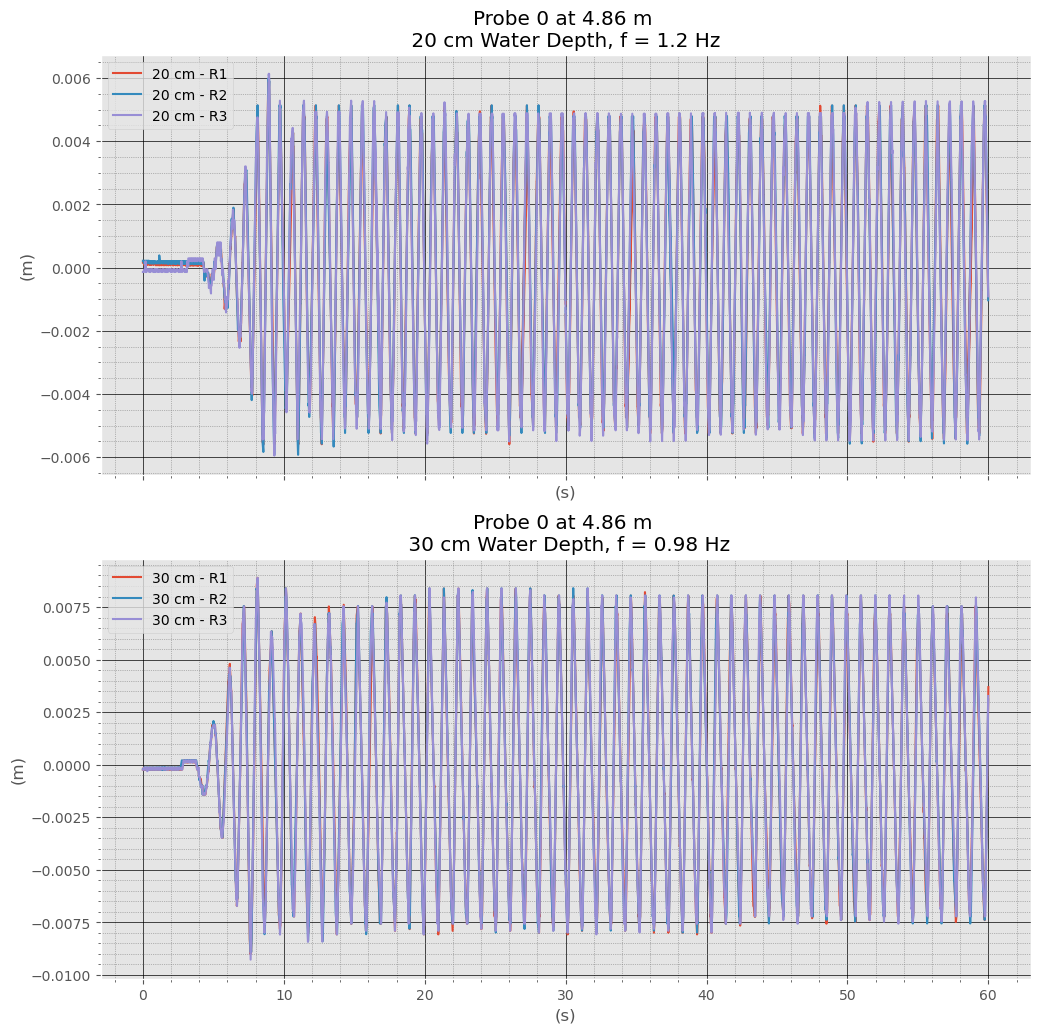

In [36]:
# Plot the time series of the first probe (P_0) for both depths and all runs
fig, ax = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

ax[0].plot(r1_20['time'], r1_20['P_0'], label='20 cm - R1')
ax[0].plot(r2_20['time'], r2_20['P_0'], label='20 cm - R2')
ax[0].plot(r3_20['time'], r3_20['P_0'], label='20 cm - R3')
ax[0].set_title(f'Probe 0 at {x_probe_pos[0]} m \n 20 cm Water Depth, f = {freq1} Hz ')
ax[0].set_xlabel('(s)')
ax[0].set_ylabel('(m)')
ax[0].legend()

ax[1].plot(r1_30['time'], r1_30['P_0'], label='30 cm - R1')
ax[1].plot(r2_30['time'], r2_30['P_0'], label='30 cm - R2')
ax[1].plot(r3_30['time'], r3_30['P_0'], label='30 cm - R3')
ax[1].set_title(f'Probe 0 at {x_probe_pos[0]} m \n 30 cm Water Depth, f = {freq2} Hz')
ax[1].set_xlabel('(s)')
ax[1].set_ylabel('(m)')
ax[1].legend()

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.minorticks_on()

In [37]:
# Cut off initial wave maker build-up time and parts that contain reflections
wave_maker_build_up_time = 12

r1_20 = cut_out_valid_data(r1_20, 1.2, 0.2, wave_maker_build_up_time, x_probe_pos)
r2_20 = cut_out_valid_data(r2_20, 1.2, 0.2, wave_maker_build_up_time, x_probe_pos)
r3_20 = cut_out_valid_data(r3_20, 1.2, 0.2, wave_maker_build_up_time, x_probe_pos)

r1_30 = cut_out_valid_data(r1_30, 0.980, 0.3, wave_maker_build_up_time, x_probe_pos)
r2_30 = cut_out_valid_data(r2_30, 0.980, 0.3, wave_maker_build_up_time, x_probe_pos)
r3_30 = cut_out_valid_data(r3_30, 0.980, 0.3, wave_maker_build_up_time, x_probe_pos)

----- Cutting out invalid data -----
Time after transient front reaches each probe: [12.         16.51851852 19.43209877 22.59259259]

Reflection arrival times at each probe: [51.85167095 47.14022319 44.10224048 40.80680161]

Time window between build-up and reflection at each probe: [39.85167095 30.62170467 24.67014172 18.21420902]

Maximum number of usable wave periods at each probe: [47.82200513 36.7460456  29.60417006 21.85705082]
-------------------------------------------------
----- Cutting out invalid data -----
Time after transient front reaches each probe: [12.         16.51851852 19.43209877 22.59259259]

Reflection arrival times at each probe: [51.85167095 47.14022319 44.10224048 40.80680161]

Time window between build-up and reflection at each probe: [39.85167095 30.62170467 24.67014172 18.21420902]

Maximum number of usable wave periods at each probe: [47.82200513 36.7460456  29.60417006 21.85705082]
-------------------------------------------------
----- Cutting out inva

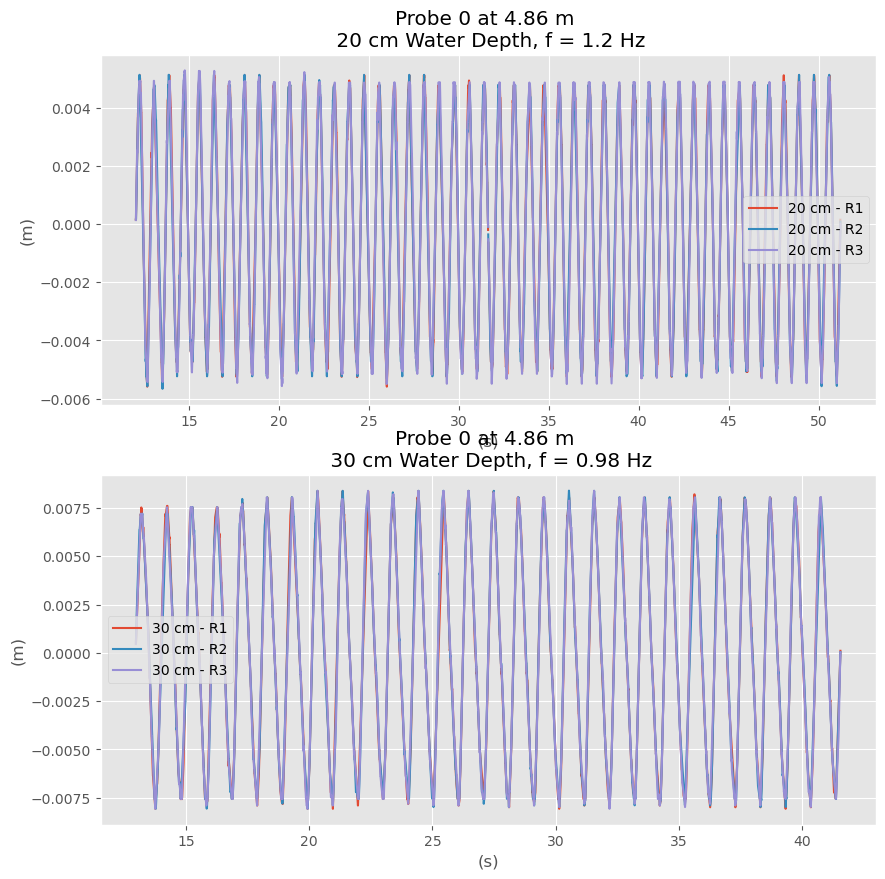

In [38]:
# Plot the time series of the first probe (P_0) for both depths and all runs again after cutting
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

ax[0].plot(r1_20['time'], r1_20['P_0'], label='20 cm - R1')
ax[0].plot(r2_20['time'], r2_20['P_0'], label='20 cm - R2')
ax[0].plot(r3_20['time'], r3_20['P_0'], label='20 cm - R3')
ax[0].set_title(f'Probe 0 at {x_probe_pos[0]} m \n 20 cm Water Depth, f = {freq1} Hz')
ax[0].set_xlabel('(s)')
ax[0].set_ylabel('(m)')
ax[0].legend()

ax[1].plot(r1_30['time'], r1_30['P_0'], label='30 cm - R1')
ax[1].plot(r2_30['time'], r2_30['P_0'], label='30 cm - R2')
ax[1].plot(r3_30['time'], r3_30['P_0'], label='30 cm - R3')
ax[1].set_title(f'Probe 0 at {x_probe_pos[0]} m \n 30 cm Water Depth, f = {freq2} Hz')
ax[1].set_xlabel('(s)')
ax[1].set_ylabel('(m)')
ax[1].legend()

In [39]:
# Calculating standard deviations and amplitudes for probe 0 - per run and depth
std_R1_20_P0 = np.std(r1_20['P_0'])
std_R2_20_P0 = np.std(r2_20['P_0'])
std_R3_20_P0 = np.std(r3_20['P_0'])

std_R1_30_P0 = np.std(r1_30['P_0'])
std_R2_30_P0 = np.std(r2_30['P_0'])
std_R3_30_P0 = np.std(r3_30['P_0'])

amp_R1_20_P0 = std_R1_20_P0 * np.sqrt(2)
amp_R2_20_P0 = std_R2_20_P0 * np.sqrt(2)
amp_R3_20_P0 = std_R3_20_P0 * np.sqrt(2)

amp_R1_30_P0 = std_R1_30_P0 * np.sqrt(2)
amp_R2_30_P0 = std_R2_30_P0 * np.sqrt(2)
amp_R3_30_P0 = std_R3_30_P0 * np.sqrt(2)

In [40]:
# Calculating standard deviations and amplitudes for probe 1 - per run and depth
std_R1_20_P1 = np.std(r1_20['P_1'])
std_R2_20_P1 = np.std(r2_20['P_1'])
std_R3_20_P1 = np.std(r3_20['P_1'])

std_R1_30_P1 = np.std(r1_30['P_1'])
std_R2_30_P1 = np.std(r2_30['P_1'])
std_R3_30_P1 = np.std(r3_30['P_1'])

amp_R1_20_P1 = std_R1_20_P1 * np.sqrt(2)
amp_R2_20_P1 = std_R2_20_P1 * np.sqrt(2)
amp_R3_20_P1 = std_R3_20_P1 * np.sqrt(2)

amp_R1_30_P1 = std_R1_30_P1 * np.sqrt(2)
amp_R2_30_P1 = std_R2_30_P1 * np.sqrt(2)
amp_R3_30_P1 = std_R3_30_P1 * np.sqrt(2)

In [41]:
# Calculating standard deviations and amplitudes for probe 2 - per run and depth
std_R1_20_P2 = np.std(r1_20['P_2'])
std_R2_20_P2 = np.std(r2_20['P_2'])
std_R3_20_P2 = np.std(r3_20['P_2'])

std_R1_30_P2 = np.std(r1_30['P_2'])
std_R2_30_P2 = np.std(r2_30['P_2'])
std_R3_30_P2 = np.std(r3_30['P_2'])

amp_R1_20_P2 = std_R1_20_P2 * np.sqrt(2)
amp_R2_20_P2 = std_R2_20_P2 * np.sqrt(2)
amp_R3_20_P2 = std_R3_20_P2 * np.sqrt(2)

amp_R1_30_P2 = std_R1_30_P2 * np.sqrt(2)
amp_R2_30_P2 = std_R2_30_P2 * np.sqrt(2)
amp_R3_30_P2 = std_R3_30_P2 * np.sqrt(2)

In [42]:
# Calculating standard deviations and amplitudes for probe 3 - per run and depth
std_R1_20_P3 = np.std(r1_20['P_3'])
std_R2_20_P3 = np.std(r2_20['P_3'])
std_R3_20_P3 = np.std(r3_20['P_3'])

std_R1_30_P3 = np.std(r1_30['P_3'])
std_R2_30_P3 = np.std(r2_30['P_3'])
std_R3_30_P3 = np.std(r3_30['P_3'])

amp_R1_20_P3 = std_R1_20_P3 * np.sqrt(2)
amp_R2_20_P3 = std_R2_20_P3 * np.sqrt(2)
amp_R3_20_P3 = std_R3_20_P3 * np.sqrt(2)

amp_R1_30_P3 = std_R1_30_P3 * np.sqrt(2)
amp_R2_30_P3 = std_R2_30_P3 * np.sqrt(2)
amp_R3_30_P3 = std_R3_30_P3 * np.sqrt(2)

In [43]:
amps_20_R1 = [amp_R1_20_P0, amp_R1_20_P1, amp_R1_20_P2, amp_R1_20_P3]
amps_20_R2 = [amp_R2_20_P0, amp_R2_20_P1, amp_R2_20_P2, amp_R2_20_P3]
amps_20_R3 = [amp_R3_20_P0, amp_R3_20_P1, amp_R3_20_P2, amp_R3_20_P3]

amps_30_R1 = [amp_R1_30_P0, amp_R1_30_P1, amp_R1_30_P2, amp_R1_30_P3]
amps_30_R2 = [amp_R2_30_P0, amp_R2_30_P1, amp_R2_30_P2, amp_R2_30_P3]
amps_30_R3 = [amp_R3_30_P0, amp_R3_30_P1, amp_R3_30_P2, amp_R3_30_P3]

# Mean amplitudes per probe over the three runs
mean_amp_20_P0 = np.mean([amp_R1_20_P0, amp_R2_20_P0, amp_R3_20_P0])
mean_amp_30_P0 = np.mean([amp_R1_30_P0, amp_R2_30_P0, amp_R3_30_P0])

mean_amp_20_P1 = np.mean([amp_R1_20_P1, amp_R2_20_P1, amp_R3_20_P1])
mean_amp_30_P1 = np.mean([amp_R1_30_P1, amp_R2_30_P1, amp_R3_30_P1])

mean_amp_20_P2 = np.mean([amp_R1_20_P2, amp_R2_20_P2, amp_R3_20_P2])
mean_amp_30_P2 = np.mean([amp_R1_30_P2, amp_R2_30_P2, amp_R3_30_P2])

mean_amp_20_P3 = np.mean([amp_R1_20_P3, amp_R2_20_P3, amp_R3_20_P3])
mean_amp_30_P3 = np.mean([amp_R1_30_P3, amp_R2_30_P3, amp_R3_30_P3])

# Gathering mean amplitudes into lists for easier plotting later
amps_20 = [mean_amp_20_P0, mean_amp_20_P1, mean_amp_20_P2, mean_amp_20_P3]
amps_30 = [mean_amp_30_P0, mean_amp_30_P1, mean_amp_30_P2, mean_amp_30_P3]

In [44]:
# Standard error
errors_20 = []
errors_20.append(np.mean([std_R1_20_P0, std_R2_20_P0, std_R3_20_P0]) / np.sqrt(np.mean([len(r1_20['P_0']), len(r2_20['P_0']), len(r3_20['P_0'])])))
errors_20.append(np.mean([std_R1_20_P1, std_R2_20_P1, std_R3_20_P1]) / np.sqrt(np.mean([len(r1_20['P_1']), len(r2_20['P_1']), len(r3_20['P_1'])])))
errors_20.append(np.mean([std_R1_20_P2, std_R2_20_P2, std_R3_20_P2]) / np.sqrt(np.mean([len(r1_20['P_2']), len(r2_20['P_2']), len(r3_20['P_2'])])))
errors_20.append(np.mean([std_R1_20_P3, std_R2_20_P3, std_R3_20_P3]) / np.sqrt(np.mean([len(r1_20['P_3']), len(r2_20['P_3']), len(r3_20['P_3'])])))

In [45]:
# Standard error
errors_30 = []
errors_30.append(np.mean([std_R1_30_P0, std_R2_30_P0, std_R3_30_P0]) / np.sqrt(np.mean([len(r1_30['P_0']), len(r2_30['P_0']), len(r3_30['P_0'])])))
errors_30.append(np.mean([std_R1_30_P1, std_R2_30_P1, std_R3_30_P1]) / np.sqrt(np.mean([len(r1_30['P_1']), len(r2_30['P_1']), len(r3_30['P_1'])])))
errors_30.append(np.mean([std_R1_30_P2, std_R2_30_P2, std_R3_30_P2]) / np.sqrt(np.mean([len(r1_30['P_2']), len(r2_30['P_2']), len(r3_30['P_2'])])))
errors_30.append(np.mean([std_R1_30_P3, std_R2_30_P3, std_R3_30_P3]) / np.sqrt(np.mean([len(r1_30['P_3']), len(r2_30['P_3']), len(r3_30['P_3'])])))

In [46]:
# Linear regression of amplitude vs probe position
coeff_20 = np.polyfit(x_probe_pos, amps_20, 1)  
line_20 = np.poly1d(coeff_20)           
r2_score_20 = r2_score(amps_20, line_20(x_probe_pos))

coeff_30 = np.polyfit(x_probe_pos, amps_30, 1)  
line_30 = np.poly1d(coeff_30)           
r2_score_30 = r2_score(amps_30, line_30(x_probe_pos))

Text(0.5, 0.98, 'Amplitude vs Probe Position with Linear Fit')

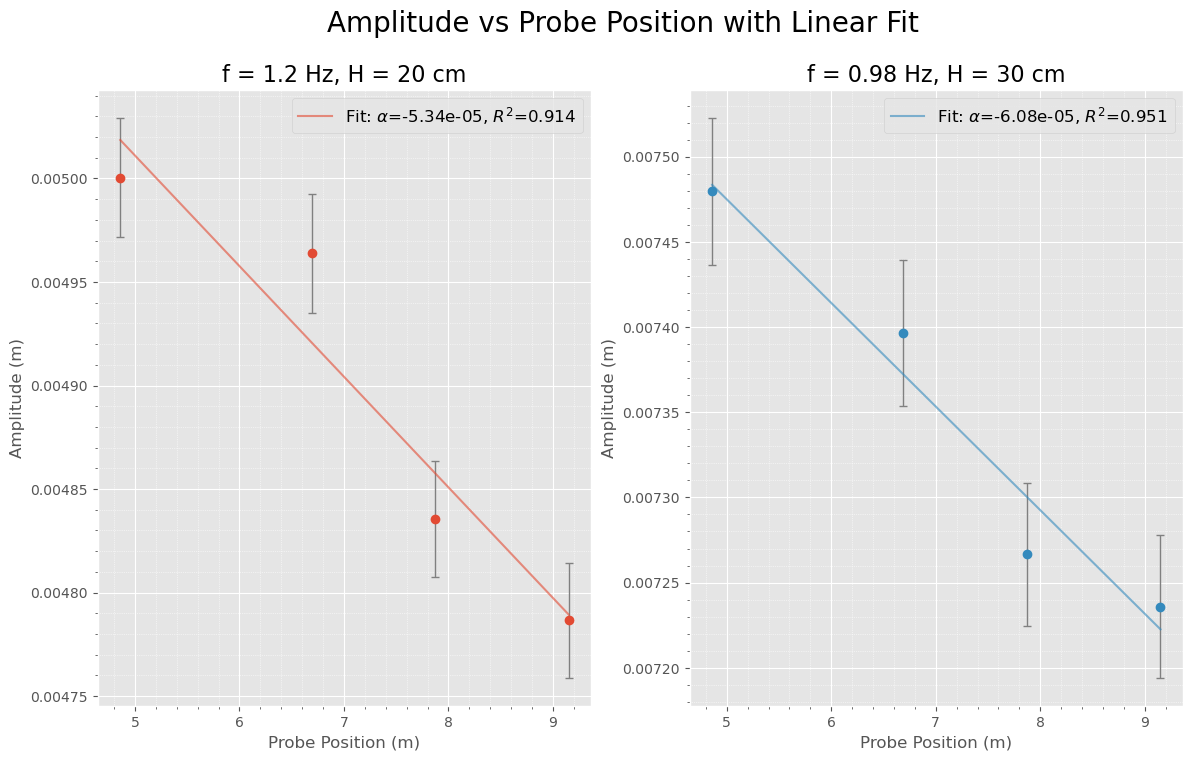

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

ax[0].errorbar(x_probe_pos,
            amps_20,
            yerr=errors_20,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

ax[1].errorbar(x_probe_pos,
            amps_30,
            mfc = 'C1',
            mec = 'C1',
            yerr=errors_30,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax[0].plot(xx, line_20(xx), color= 'C0', alpha=0.6,
         label=rf'Fit: $\alpha$={coeff_20[0]:.2e}, $R^2$={r2_score_20:.3f}')

ax[1].plot(xx, line_30(xx), color= 'C1', alpha=0.6,
         label=rf'Fit: $\alpha$={coeff_30[0]:.2e}, $R^2$={r2_score_30:.3f}')

ax[0].grid(which='minor', linestyle=':', linewidth='0.5', color='white')
ax[0].minorticks_on()

ax[1].grid(which='minor', linestyle=':', linewidth='0.5', color='white')
ax[1].minorticks_on()

ax[0].set_xlabel('Probe Position (m)', fontsize=12)
ax[0].set_ylabel('Amplitude (m)', fontsize=12)
ax[0].set_title(f'f = {freq1} Hz, H = 20 cm', fontsize=16)
ax[0].legend(fontsize=12)

ax[1].set_xlabel('Probe Position (m)', fontsize=12)
ax[1].set_ylabel('Amplitude (m)', fontsize=12)
ax[1].set_title(f'f = {freq2} Hz, H = 30 cm', fontsize=16)
ax[1].legend(fontsize=12)

fig.suptitle('Amplitude vs Probe Position with Linear Fit', fontsize=20)

In [48]:
k_20 = estimate_wavenumber(freq1, 0.2)
k_30 = estimate_wavenumber(freq2, 0.3)

ak_20_P0 = mean_amp_20_P0 * k_20
ak_30_P0 = mean_amp_30_P0 * k_30

kh_20 = k_20 * 0.2
kh_30 = k_30 * 0.3

In [49]:
# Decay rate
amp_change_20 = amps_20[0] - amps_20[-1]
amp_change_30 = amps_30[0] - amps_30[-1]

decay_rate_20 = amp_change_20 / (x_probe_pos[-1] - x_probe_pos[0])
decay_rate_30 = amp_change_30 / (x_probe_pos[-1] - x_probe_pos[0])

In [50]:
print("Summary of results:")
print()
print(f"20 cm water depth:\n")
print(f'Amplitude at P0: {mean_amp_20_P0:.4f} m')
print(f'ak = {ak_20_P0:.4f}, kH = {kh_20:.4f}')
print(f"Amplitude change: {amp_change_20:.4f} m")
print(f"Decay rate: {decay_rate_20:.4f} m/m")
print('-------------------------')
print(f"30 cm water depth:\n")
print(f'Target ampltude at P0: {target_amp:.5f} m')
print(f'Observed amplitude at P0: {mean_amp_30_P0:.4f} m')
print(f'ak = {ak_30_P0:.4f}, kH = {kh_30:.4f}')
print(f"Amplitude change: {amp_change_30:.4f} m")
print(f"Decay rate: {decay_rate_30:.4f} m/m")
print('-------------------------')
print(f'% difference from target amplitude at P0: {((mean_amp_30_P0 - target_amp) / target_amp) * 100:.4f} %')
print(f'% difference in ak: {((ak_30_P0 - (target_amp * k_30)) / (target_amp * k_30)) * 100:.4f} %')
print(f'% difference in kH: {((kh_30 - (k_30 * 0.3)) / (k_30 * 0.3)) * 100:.4f} %')

Summary of results:

20 cm water depth:

Amplitude at P0: 0.0050 m
ak = 0.0333, kH = 1.3324
Amplitude change: 0.0002 m
Decay rate: 0.0000 m/m
-------------------------
30 cm water depth:

Target ampltude at P0: 0.00750 m
Observed amplitude at P0: 0.0075 m
ak = 0.0332, kH = 1.3328
Amplitude change: 0.0002 m
Decay rate: 0.0001 m/m
-------------------------
% difference from target amplitude at P0: -0.2714 %
% difference in ak: -0.2714 %
% difference in kH: 0.0000 %


## Comparing the experiments across depth by nondimensionalization

In [51]:
def make_dimensionless(eta, depth, t):
    """
    Convert amplitude to dimensionless form.
    """
    eta_star = eta / depth 
    t_star = np.sqrt(9.81 / depth) * t
    
    return eta_star, t_star

Text(0.5, 0.98, 'Dimensionless Surface Elevation at Probe 0 for Both Depths')

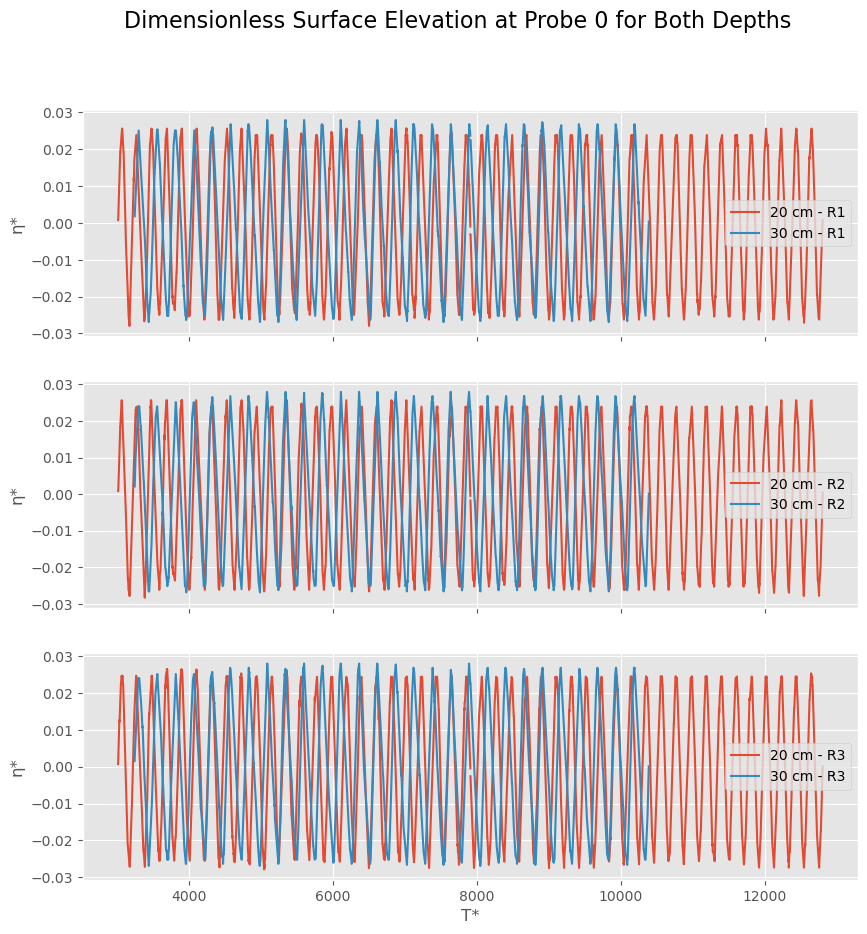

In [52]:
eta_non_20_R1_P0, t_non_20 = make_dimensionless(r1_20['P_0'], 0.2, r1_20['time'])
eta_non_30_R1_P0, t_non_30 = make_dimensionless(r1_30['P_0'], 0.3, r1_30['time'])

eta_non_20_R2_P0, _ = make_dimensionless(r2_20['P_0'], 0.2, r2_20['time'])
eta_non_30_R2_P0, _ = make_dimensionless(r2_30['P_0'], 0.3, r2_30['time'])

eta_non_20_R3_P0, _ = make_dimensionless(r3_20['P_0'], 0.2, r3_20['time'])
eta_non_30_R3_P0, _ = make_dimensionless(r3_30['P_0'], 0.3, r3_30['time'])

fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax[0].plot(eta_non_20_R1_P0, label='20 cm - R1')
ax[0].plot(eta_non_30_R1_P0, label='30 cm - R1')

ax[1].plot(eta_non_20_R2_P0, label='20 cm - R2')
ax[1].plot(eta_non_30_R2_P0, label='30 cm - R2')

ax[2].plot(eta_non_20_R3_P0, label='20 cm - R3')
ax[2].plot(eta_non_30_R3_P0, label='30 cm - R3')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[2].set_xlabel('T*')
ax[0].set_ylabel('η*')
ax[1].set_ylabel('η*')
ax[2].set_ylabel('η*')

fig.suptitle('Dimensionless Surface Elevation at Probe 0 for Both Depths', fontsize=16)

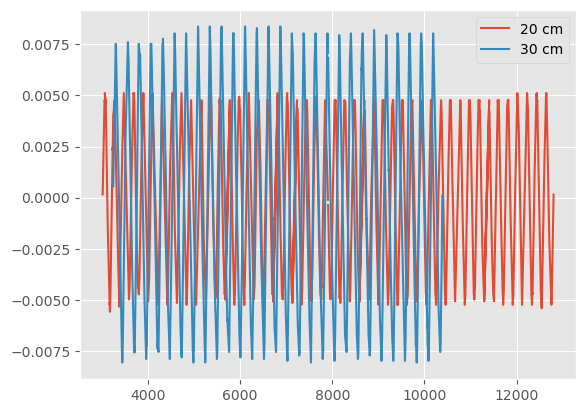

In [53]:
plt.plot(r1_20['P_0'], label='20 cm')
plt.plot(r1_30['P_0'], label='30 cm')

plt.legend()

In [54]:
np.std(r1_30['P_0'])/np.std(r1_20['P_0'])

1.4999545449841818